In [1]:
import numpy as np
import pandas as pd
import jax
import jax.numpy as jnp
import jax.random as jr
import optax
import time
import matplotlib.pyplot as plt

In [2]:
tau = [jnp.linspace(0, 20, 41),
       jnp.linspace(0, 20, 41)]

hyperparameters = {
    "theta" : jnp.array([0.2, 0.2, 3.0]),
    "X0" : jnp.array([-1.0, 1.0]),
    "sigma" : jnp.array([0.2, 0.2]),
    "tau" : tau,
    # "obs_times" : test_helpers.obs_matrix(tau),
    "I" : jnp.linspace(0, 20, int(160 +1))
}

def ode(X, theta, t=None):
    '''
    X : n x D
    theta : p

    return : n x D
    '''
    n = X.shape[0]
    V, R = X.T
    a, b, c = theta # theta.repeat([n, 1]).T

    return jnp.stack([c * (V - V**3/3 + R),
                        -1/c * (V - a + b*R)])

In [3]:
data = pd.read_csv('y.csv').to_numpy()
I = np.arange(0, 20.1, 0.125)
full = np.full((I.shape[0], data.shape[1]), np.nan)
full[:,0] = I
full[np.isin(full[:,0], data[:,0])] = data

# pd.DataFrame(full).to_csv('y_disc.csv', index=False)

In [4]:
from magi import MAGI

In [51]:
start = time.time()
solver = MAGI(ode, full, [1, 1, 1], theta_conf=[0,0,0], sigmas=[0.2, 0.2])

solver.put(jnp.float32, jax.devices()[0])

sd_init = 0.01
x0 = jr.normal(jr.PRNGKey(20), shape=(200, solver.particles_init.shape[0]), dtype=jnp.float32) * sd_init + solver.particles_init
x0 = x0.at[:,-2:].set(jnp.abs(x0[:,-2:]))

solver.solve(x0, mitosis_splits=3, optimizer_kwargs={'learning_rate': 0.1}, atol=0.1, rtol=0, max_iter=300)
end = time.time()
print(f"Elapsed time: {end - start:.4f}")

Split 0 finished after 300 iterations | max grad = 585.15204
Split 1 finished after 300 iterations | max grad = 273.90024
Split 2 finished after 300 iterations | max grad = 720.24280
Split 3 finished after 300 iterations | max grad = 222.31908
Elapsed time: 5.6396


In [41]:
solver.particles

Array([[0.2047293 , 0.31242085, 2.9381747 , ..., 0.32068294, 1.8752848 ,
        0.24466412],
       [0.20917524, 0.32472765, 2.920268  , ..., 0.3225909 , 1.8769381 ,
        0.24603851],
       [0.222157  , 0.30634287, 2.9227996 , ..., 0.32239544, 1.8761753 ,
        0.2466729 ],
       ...,
       [0.1887632 , 0.24193664, 3.0378277 , ..., 0.41214222, 1.9076232 ,
        0.33553147],
       [0.21483505, 0.21748866, 3.0330415 , ..., 0.4133309 , 1.9083459 ,
        0.33827323],
       [0.22749208, 0.2845703 , 2.984577  , ..., 0.36568567, 1.890939  ,
        0.2897777 ]], dtype=float32)

# Seems like initialization is wrong, numerical stability issues with computing matrices

In [42]:
solver.phis

Array([[2.1334085 , 1.3102835 ],
       [0.45490193, 2.0049021 ]], dtype=float32)

In [43]:
solver.K_invs.mean()

Array(277.1057, dtype=float32)

In [44]:
diags = [jnp.diag(c) for c in solver.K_invs]

In [45]:
particles = solver.particles
theta = particles[:,:solver.p] # (p,)
X = jnp.reshape(particles[:,solver.p:solver.p+solver.D*solver.n], (particles.shape[0], solver.n, solver.D)) # (n, d)
# sigmas = solver.sigmas.at[:,solver.unknown_sigmas].set(jnp.clip(particles[:,solver.p+solver.D*solver.n:], min=1e-5)) # (d,)

In [46]:
particles.shape

(1600, 325)

In [47]:
theta.mean(axis=0)

Array([0.20116897, 0.3002006 , 2.9561188 ], dtype=float32)

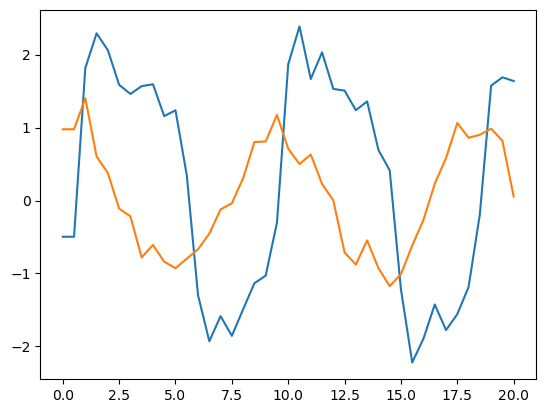

In [48]:
plt.plot(solver.I,  jnp.reshape(solver.particles_init[solver.p:solver.p+solver.D*solver.n], (solver.n, solver.D)) )

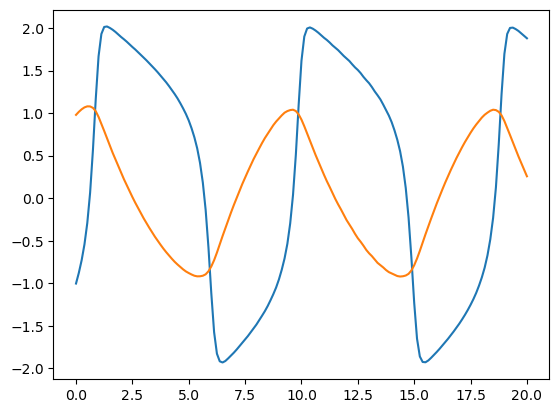

In [49]:
plt.plot(solver.I, X.mean(axis=0)[:,0])
plt.plot(solver.I, X.mean(axis=0)[:,1])